# 02 — ค้นพบกระบวนการจริง (Process Discovery)

ใช้ log ที่ทำไว้ใน `01_explore` (1 เคส = 1 ใบขอซื้อ PR และเอกสารที่ตามมา, 927 เคส)
คำถามที่ตอบ: กระบวนการจริงมีกี่แบบ (variants) และกี่แบบครอบคลุมงานส่วนใหญ่ หน้าตากระบวนการหลักเป็นอย่างไร
ข้อมูลเป็น **ข้อมูลจำลอง** ทุกข้อสรุปเกี่ยวกับสาเหตุเป็นข้อสันนิษฐาน

In [1]:
import os; os.environ['PM4PY_SHOW_PROGRESS_BAR'] = 'False'
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))
import pandas as pd, matplotlib.pyplot as plt, pm4py
import p2p_data as d, p2p_viz as viz
FIG = Path.cwd().parent / 'figures'; R = {}
df = d.load_case_log()
log = pm4py.format_dataframe(df, case_id='case:concept:name', activity_key='concept:name', timestamp_key='time:timestamp')
R['cases'] = int(df['case:concept:name'].nunique()); R['events'] = len(df)
R['cases'], R['events']

(927, 14671)

## 1. Variants แบบเต็ม (ลำดับ activity ทุกตัว)

In [2]:
trace = df.groupby('case:concept:name')['concept:name'].apply(tuple)
vc = trace.value_counts()
cum = vc.cumsum() / vc.sum() * 100
R['variants_full'] = len(vc)
R['variants_full_singletons'] = int((vc==1).sum())
R['top1_coverage_pct'] = round(cum.iloc[0],1); R['top5_coverage_pct'] = round(cum.iloc[4],1)
R['top10_coverage_pct'] = round(cum.iloc[9],1)
R['variants_needed_for_50pct'] = int((cum < 50).sum() + 1)
R['variants_needed_for_80pct'] = int((cum < 80).sum() + 1)
{k:R[k] for k in ['variants_full','variants_full_singletons','top1_coverage_pct','top5_coverage_pct','top10_coverage_pct','variants_needed_for_50pct','variants_needed_for_80pct']}

{'variants_full': 388,
 'variants_full_singletons': 330,
 'top1_coverage_pct': np.float64(19.5),
 'top5_coverage_pct': np.float64(37.4),
 'top10_coverage_pct': np.float64(44.8),
 'variants_needed_for_50pct': 15,
 'variants_needed_for_80pct': 203}

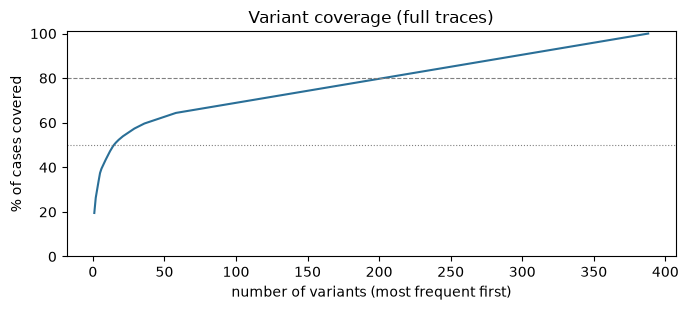

In [3]:
fig, ax = plt.subplots(figsize=(7,3.2))
ax.plot(range(1, len(cum)+1), cum.values, color='#2a6f97')
ax.axhline(80, ls='--', color='grey', lw=.8); ax.axhline(50, ls=':', color='grey', lw=.8)
ax.set_xlabel('number of variants (most frequent first)'); ax.set_ylabel('% of cases covered')
ax.set_title('Variant coverage (full traces)'); ax.set_ylim(0,101)
fig.tight_layout(); fig.savefig(FIG/'02_variant_coverage.png', dpi=150)

variants แตกเป็นหลายร้อยแบบ แต่ไม่ได้แปลว่ากระบวนการยุ่ง ต้องดูว่าความต่างมาจากไหน
สมมติฐาน: ความต่างส่วนใหญ่มาจาก *จำนวน* เอกสารต่อเคส (จำนวน PO, GR, invoice) และการสลับลำดับระหว่างเอกสารคนละใบ ไม่ใช่เส้นทางที่ต่างกันจริง

## 2. แยกที่มาของความหลากหลาย

In [4]:
def collapse(t):
    out = []
    for a in t:
        if not out or out[-1] != a: out.append(a)
    return tuple(out)
skeleton = trace.map(lambda t: tuple(dict.fromkeys(t)))      # ลำดับครั้งแรกของแต่ละ activity
collapsed = trace.map(collapse)                               # รวม activity เดียวกันที่ติดกัน
R['variants_collapsed'] = int(collapsed.nunique())
R['variants_skeleton'] = int(skeleton.nunique())
sk = skeleton.value_counts()
R['skeleton_variants'] = {' > '.join(map(d.short,k)): int(v) for k,v in sk.items()}
pd.DataFrame({'variants': [R['variants_full'], R['variants_collapsed'], R['variants_skeleton']]},
             index=['full trace','repeated steps collapsed','first occurrence only (skeleton)'])

,variants
full trace,388
repeated steps collapsed,247
first occurrence only (skeleton),3


In [5]:
pd.Series(R['skeleton_variants'], name='cases').to_frame()

,cases
Create PR > Approve PR > Create RFQ > Create PO > Approve PO > Create GR > Create Invoice > Two-Way Match > Execute Payment,607
Create RFQ > Create PO > Approve PO > Create GR > Create Invoice > Two-Way Match > Execute Payment,198
Create PR > Delegate PR Approval > Create RFQ > Create PO > Approve PO > Create GR > Create Invoice > Two-Way Match > Execute Payment,122


In [6]:
# จำนวนเอกสารต่อเคส vs. จำนวน variants
con = d.connect(); xo = d.event_object_table(con)
case_of_event = df.set_index('ocel_event_id')['case:concept:name']
xo['case'] = xo.ocel_event_id.map(case_of_event)
docs = xo[xo.object_type.isin(['purchase_order','goods receipt','invoice receipt'])].groupby(['case','object_type']).ocel_object_id.nunique().unstack(fill_value=0)
docs.columns = ['GRs','invoices','POs']
docs = docs[['POs','GRs','invoices']]
docs['variant'] = trace.reindex(docs.index).values
docs['shape'] = docs.POs.astype(str)+' PO / '+docs.GRs.astype(str)+' GR'
shape = docs.groupby('shape').agg(cases=('variant','size'), variants=('variant','nunique')).sort_values('cases', ascending=False)
R['doc_shapes'] = shape.reset_index().to_dict('records')
R['cases_single_po_single_gr'] = int(((docs.POs==1)&(docs.GRs==1)).sum())
shape.head(12)

,cases,variants
shape,,
1 PO / 1 GR,345,11
2 PO / 2 GR,162,81
1 PO / 2 GR,102,13
3 PO / 3 GR,92,88
2 PO / 3 GR,75,70
4 PO / 4 GR,55,55
1 PO / 3 GR,37,12
3 PO / 4 GR,36,36
2 PO / 4 GR,13,13


In [7]:
# ภายในกลุ่มที่มี PO 1 ใบ GR 1 ใบ เหลือกี่ variants
one = docs[(docs.POs==1)&(docs.GRs==1)]
R['variants_in_single_po_single_gr'] = int(one.variant.nunique())
R['cases_single_po_single_gr'], R['variants_in_single_po_single_gr']

(345, 11)

**อ่านผล:** ถ้าตัดเรื่องจำนวนเอกสารออก (skeleton) เหลือเส้นทางหลักเพียงไม่กี่แบบ ความหลากหลายเกือบทั้งหมดมาจากเคสที่มีหลาย PO/GR
ในข้อมูลจริงมักไม่สะอาดขนาดนี้ เป็นอีกหนึ่งสัญญาณว่าเป็นข้อมูลจำลอง

## 3. Directly-follows graph (DFG) ของทั้ง log

In [8]:
dfg, sa, ea = pm4py.discover_dfg(log)
R['dfg_edges'] = len(dfg)
R['start_activities'] = dict(sa); R['end_activities'] = dict(ea)
act_counts = df['concept:name'].value_counts().to_dict()
# วาดเองด้วยสไตล์ของโปรเจกต์ (จุดเริ่ม/จบขนาดเท่ากัน, ตัวเลขไม่ทับเส้น); ข้อมูลมาจาก pm4py.discover_dfg
viz.dfg_graph(dfg, sa, ea, act_counts).render(str(FIG/'02_dfg_frequency'), format='png', cleanup=True)
viz.dfg_graph(dfg, sa, ea, act_counts, rankdir='TB').render(str(FIG/'02_dfg_frequency_tb'), format='png', cleanup=True)   # แนวตั้ง สำหรับรายงาน
top_edges = sorted(dfg.items(), key=lambda kv: -kv[1])
R['dfg_top_edges'] = [{'from':a,'to':b,'count':int(n)} for (a,b),n in top_edges[:12]]
pd.DataFrame(R['dfg_top_edges'])

,from,to,count
0,Create Goods Receipt,Create Goods Receipt,2386
1,Create Invoice Receipt,Perform Two-Way Match,1498
2,Create Goods Receipt,Create Invoice Receipt,1158
3,Create Purchase Order,Approve Purchase Order,1044
4,Approve Purchase Order,Create Goods Receipt,927
5,Create Request for Quotation,Create Purchase Order,927
6,Perform Two-Way Match,Execute Payment,739
7,Approve Purchase Requisition,Create Request for Quotation,607
8,Create Purchase Requisition,Approve Purchase Requisition,607
9,Approve Purchase Order,Approve Purchase Order,554


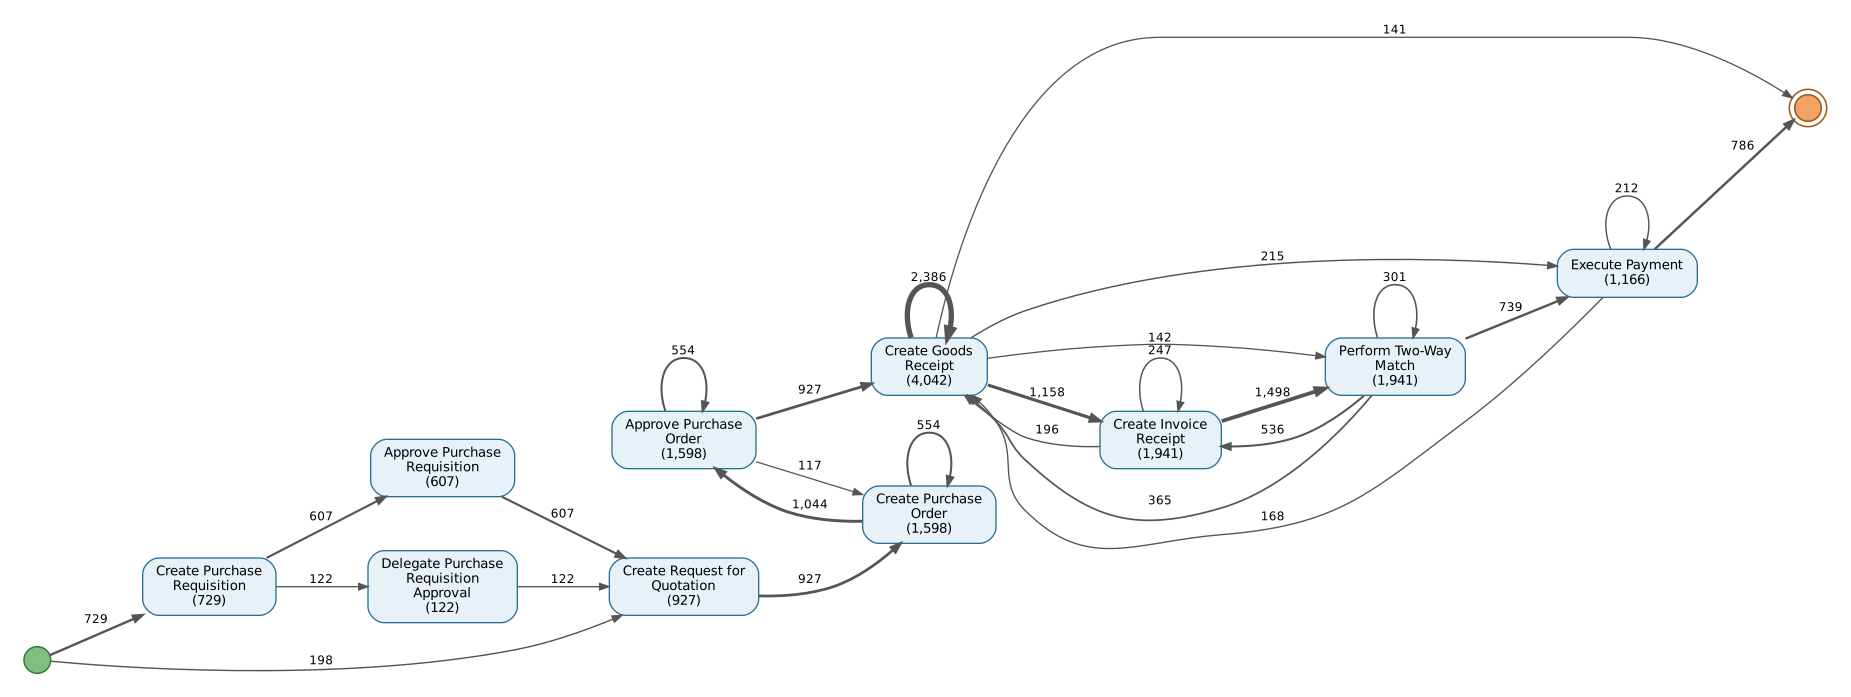

In [9]:
from IPython.display import Image; Image(str(FIG/'02_dfg_frequency.png'))

**สิ่งที่สังเกตจาก DFG** (เป็นข้อสังเกต ยังไม่ใช่ข้อสรุป)
- มี 2 จุดเริ่ม: `Create Purchase Requisition` และ `Create Request for Quotation` (ข้ามการสร้างใบขอซื้อ)
- `Execute Payment → Execute Payment` และ `Execute Payment → Create Goods Receipt` บอกว่ามีการจ่ายซ้ำและรับของหลังจ่ายเงิน จะตรวจระดับเอกสารในช่วง 4
- บางเคสจบที่ `Create Goods Receipt` ไม่ใช่ `Execute Payment`

## 4. Inductive Miner
กรองเหลือ variants ยอดนิยมที่ครอบคลุมอย่างน้อย 50% ของเคส เพื่อให้แผนภาพอ่านได้ แล้วเทียบกับโมเดลจาก log เต็มที่ใช้ noise threshold 0.2

In [10]:
k = R['variants_needed_for_50pct']
# กรอง variants ยอดนิยมด้วย pandas (pm4py.filter_variants_top_k ใช้ไม่ได้เมื่อ pandas ใช้ pyarrow เก็บข้อความ)
top_cases = trace[trace.isin(set(vc.index[:k]))].index
log_top = log[log['case:concept:name'].isin(top_cases)]
R['im_top_k'] = k
R['im_top_cases'] = int(log_top['case:concept:name'].nunique())
R['im_top_coverage_pct'] = round(100*R['im_top_cases']/R['cases'],1)
net, im, fm = pm4py.discover_petri_net_inductive(log_top)
pm4py.save_vis_petri_net(net, im, fm, str(FIG/'02_petri_top_variants.png'))
tree_top = pm4py.discover_process_tree_inductive(log_top)
R['im_top_tree'] = str(tree_top)
print(k, R['im_top_cases'], R['im_top_coverage_pct']); print(tree_top)

15 466 50.3
->( X( tau, ->( 'Create Purchase Requisition', X( 'Approve Purchase Requisition', 'Delegate Purchase Requisition Approval' ) ) ), 'Create Request for Quotation', *( 'Create Purchase Order', tau ), *( 'Approve Purchase Order', tau ), +( *( 'Create Goods Receipt', tau ), ->( *( ->( *( 'Create Invoice Receipt', tau ), *( 'Perform Two-Way Match', tau ) ), tau ), *( 'Execute Payment', tau ) ) ) )


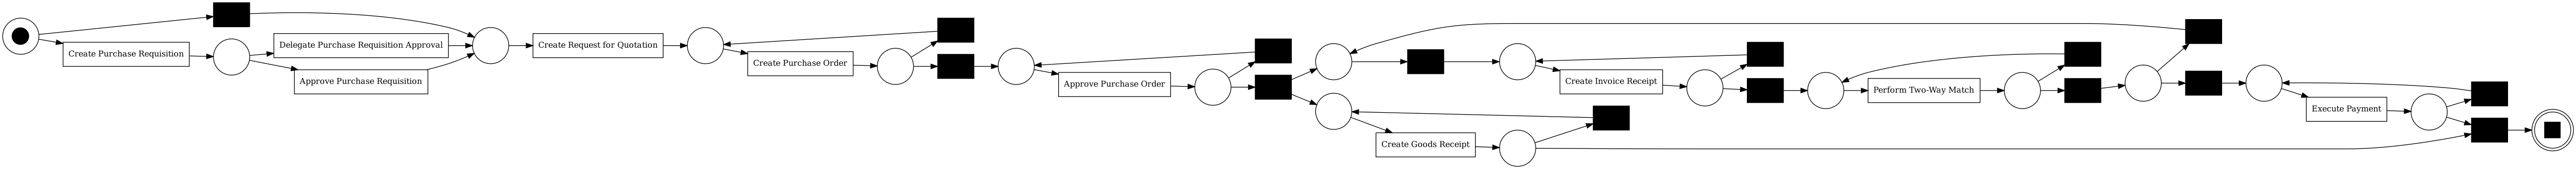

In [11]:
Image(str(FIG/'02_petri_top_variants.png'))

In [12]:
net2, im2, fm2 = pm4py.discover_petri_net_inductive(log, noise_threshold=0.2)
tree_all = pm4py.discover_process_tree_inductive(log, noise_threshold=0.2)
R['im_full_tree'] = str(tree_all)
pm4py.save_vis_petri_net(net2, im2, fm2, str(FIG/'02_petri_full_noise02.png'))
bpmn = pm4py.convert_to_bpmn(tree_all)
# วาด BPMN เอง โดยตัด gateway ที่มีเข้า 1 ออก 1 (เกิดจาก loop ของ tau) ออก ไม่เปลี่ยนความหมายของโมเดล
viz.bpmn_graph(bpmn).render(str(FIG/'02_asis_bpmn'), format='png', cleanup=True)
viz.bpmn_graph(bpmn, rankdir='TB', compact=True).render(str(FIG/'02_asis_bpmn_tb'), format='png', cleanup=True)
print(tree_all)

->( X( tau, ->( 'Create Purchase Requisition', X( 'Approve Purchase Requisition', 'Delegate Purchase Requisition Approval' ) ) ), 'Create Request for Quotation', *( 'Create Purchase Order', tau ), *( 'Approve Purchase Order', tau ), +( *( 'Create Goods Receipt', tau ), ->( *( ->( *( 'Create Invoice Receipt', tau ), *( 'Perform Two-Way Match', tau ) ), tau ), *( 'Execute Payment', tau ) ) ) )


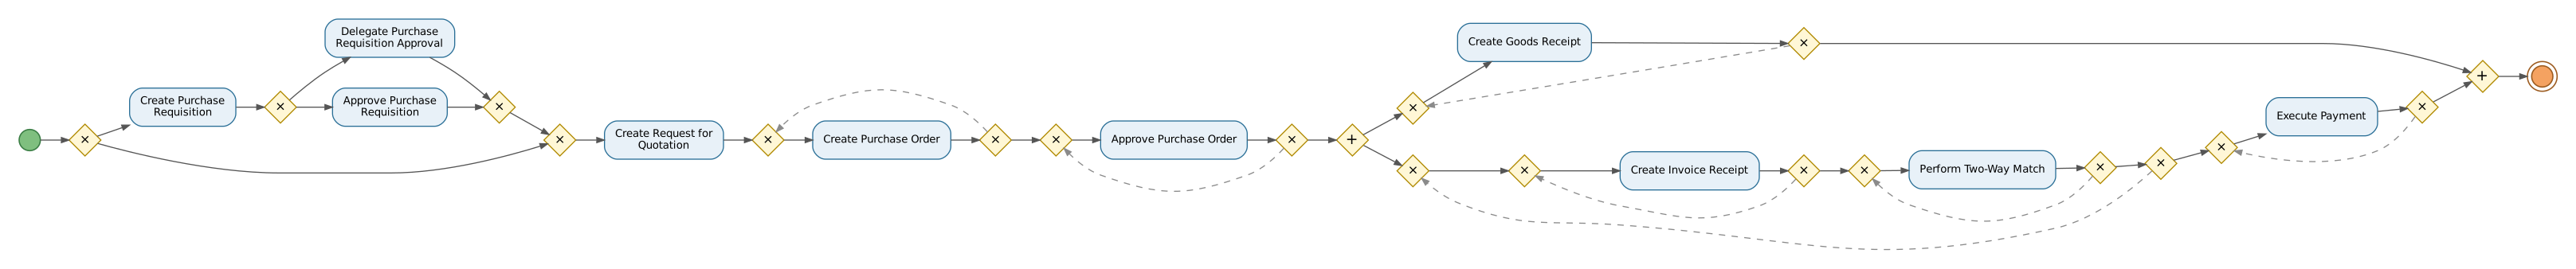

In [13]:
Image(str(FIG/'02_asis_bpmn.png'))

### คุณภาพของโมเดลที่ค้นพบ (วัดกับ log เต็ม)

In [14]:
q = {}
for name, (n,i,f) in {'top variants': (net,im,fm), 'full log, noise 0.2': (net2,im2,fm2)}.items():
    fit = pm4py.fitness_token_based_replay(log, n, i, f)
    prec = pm4py.precision_token_based_replay(log, n, i, f)
    q[name] = {'fitting_traces_pct': round(fit['perc_fit_traces'],1), 'log_fitness': round(fit['log_fitness'],3),
               'precision': round(prec,3)}
R['discovered_model_quality'] = q
R['trees_identical'] = str(tree_top) == str(tree_all)
print('two discovered trees identical:', R['trees_identical'])
pd.DataFrame(q).T

two discovered trees identical: True


,fitting_traces_pct,log_fitness,precision
top variants,87.8,0.996,0.612
"full log, noise 0.2",87.8,0.996,0.612


ทั้งสองวิธีได้ process tree ตัวเดียวกัน แปลว่าโครงหลักของกระบวนการชัดเจนพอ ไม่ว่าจะกรอง variants แบบไหน

**อ่านผล:** fitness คือโมเดลอธิบาย log ได้ดีแค่ไหน ส่วน precision คือโมเดลยอมให้เกิดพฤติกรรมที่ไม่เคยเห็นใน log มากแค่ไหน (ต่ำ = หลวมเกินไป)
โมเดลที่ค้นพบมี loop กับ parallel จำนวนมาก เพราะเคสมีเอกสารหลายใบ precision จึงต่ำ แผนภาพจึงใช้เพื่ออธิบายภาพรวม ส่วนการตรวจความถูกต้องในช่วง 4 จะใช้โมเดลอ้างอิงที่นิยามเอง

## 5. มุมมอง object-centric (OC-DFG)
ดูกระบวนการแยกตามประเภทเอกสาร โดยไม่ต้องบีบให้เป็นเคสเดียว

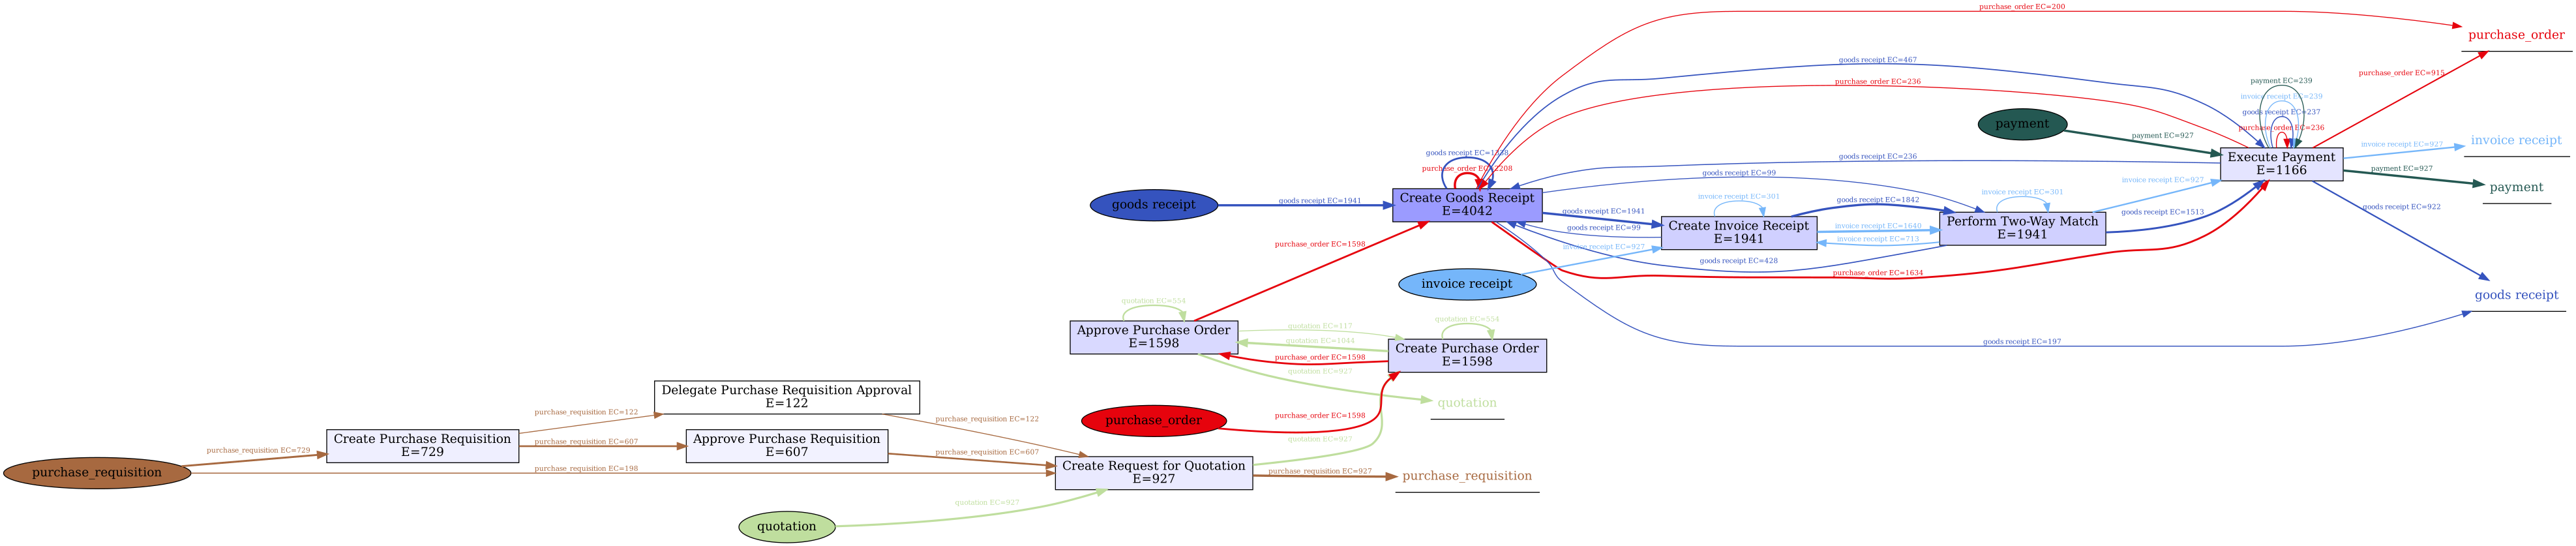

In [15]:
ocel = pm4py.read_ocel2_sqlite(str(d.DATA))
ocel_f = pm4py.filter_ocel_object_types(ocel, ['purchase_requisition','quotation','purchase_order','goods receipt','invoice receipt','payment'])
ocdfg = pm4py.discover_ocdfg(ocel_f)
pm4py.save_vis_ocdfg(ocdfg, str(FIG/'02_ocdfg.png'), annotation='frequency')
Image(str(FIG/'02_ocdfg.png'))

## 6. บันทึกตัวเลข

In [16]:
out = Path.cwd().parent/'results'/'02_discovery.json'
out.write_text(json.dumps(R, indent=2, ensure_ascii=False, default=str)); print('saved', len(R), 'keys')

saved 26 keys
